In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import matplotlib.ticker as mticker

def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu = X_t.mean().values

    Xc_t = X_t.values - mu
    Xc_tk = X_tk.values - mu

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    var = X.var(ddof=0).values
    D_inv_sqrt = np.diag(1 / np.sqrt(var))

    return D_inv_sqrt @ Sigma_k @ D_inv_sqrt

k_values = [1, 10]

In [14]:
def out_of_sample_lead_lag(n_months: int):
    years = range(2019, 2025)
    centralities = ["central", "peripheral"]
    portfolios = {}

    for year in years:
        for centrality in centralities:
            for k in k_values:
                cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}_{k}.csv", index_col="Date").columns.tolist()
                end_date = (
                    pd.Timestamp(year=year + 1, month=n_months, day=1)
                    + pd.offsets.MonthEnd(0)
                )
                portfolios[f"{centrality}_{year}_{k}"] = pd.read_parquet(f"../../data/02_clean/returns_{year + 1}.parquet").loc[:end_date, cols]

    weekly_returns = {}
    daily_returns = {}
    weekly2_returns = {}
    monthly_returns = {}
    for name, portfolio in portfolios.items():
        log_returns = np.log1p(portfolio)
        weekly_returns[name] = log_returns.resample("W-FRI").sum().mean(axis=1)
        daily_returns[name] = log_returns.mean(axis=1)
        weekly2_returns[name] = log_returns.resample("2W-FRI").sum().mean(axis=1)
        monthly_returns[name] = log_returns.resample("ME").sum().mean(axis=1)

    # ── Build one leadlag_df per k ──────────────────────────────────────────
    leadlag_by_k = {}

    for k in k_values:
        leadlag_df = {}
        for year in years:
            R1 = daily_returns[f"peripheral_{year}_{k}"]
            R2 = daily_returns[f"central_{year}_{k}"]
            R3 = weekly_returns[f"peripheral_{year}_{k}"]
            R4 = weekly_returns[f"central_{year}_{k}"]
            R5 = weekly2_returns[f"peripheral_{year}_{k}"]
            R6 = weekly2_returns[f"central_{year}_{k}"]
            R7 = monthly_returns[f"peripheral_{year}_{k}"]
            R8 = monthly_returns[f"central_{year}_{k}"]

            matrix = []
            for lag in [1]:
                for R_peri, R_cent in [(R1, R2), (R3, R4), (R5, R6), (R7, R8)]:
                    X = pd.concat([R_peri, R_cent], axis=1)
                    X.columns = ["Peripheral", "Central"]
                    acm = autocorrelation_matrix(X, lag)
                    lag_matrix = acm - acm.T
                    matrix.append(lag_matrix[1, 0])

            leadlag_df[year + 1] = pd.DataFrame(
                [np.hstack(matrix)],
                columns=["cp1d", "cp1w", "cp2w", "cp1m"]
            )

        leadlag_by_k[k] = pd.concat(leadlag_df).reset_index(level=1, drop=True)

    # --- Style ---
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    palette = sns.color_palette("colorblind")

    # --- Figure ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True, sharey=True)
    axes_flat = axes.flatten()

    panels = [
        ("cp1d", f"Next {n_months}-months 1-day lag"),
        ("cp1w", f"Next {n_months}-months 1-week lag"),
        ("cp2w", f"Next {n_months}-months 2-weeks lag"),
        ("cp1m", f"Next {n_months}-months 1-month lag"),
    ]

    # Map each k to a colour and line style
    k_styles = {
        k_values[0]: {"color": palette[0], "label": f"$k={k_values[0]}$", "marker": "o"},
        k_values[1]: {"color": palette[1], "label": f"$k={k_values[1]}$", "marker": "s"},
    }

    legend_handles = []

    for i, (ax, (col, title)) in enumerate(zip(axes_flat, panels)):
        for k, style in k_styles.items():
            df = leadlag_by_k[k]
            line, = ax.plot(
                df.index, df[col],
                lw=1.8,
                color=style["color"],
                marker=style["marker"],
                label=style["label"],
            )
            if i == 0:                          # collect handles once
                legend_handles.append(line)

        ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
        ax.tick_params(axis="both", labelsize=9)
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
        ax.set_xlabel("")

        if i % 2 == 0:
            ax.set_ylabel("Lead–Lag Measure", fontsize=10)
        else:
            ax.set_ylabel("")

    # -------- Single shared legend --------
    fig.legend(
        legend_handles,
        [h.get_label() for h in legend_handles],
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=9,
        title="Years of past data",
        title_fontsize=9,
        bbox_to_anchor=(0.5, -0.02),
    )

    sns.despine(fig=fig)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.savefig(f"../../figures/oos_leadlag_{n_months}.png", dpi=300, bbox_inches="tight")
    plt.show()

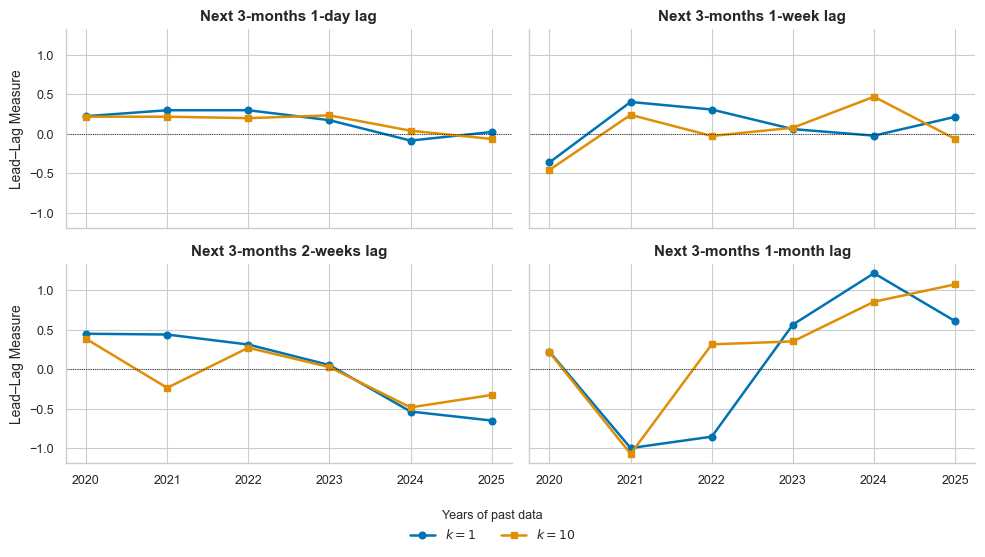

In [15]:
out_of_sample_lead_lag(n_months=3)

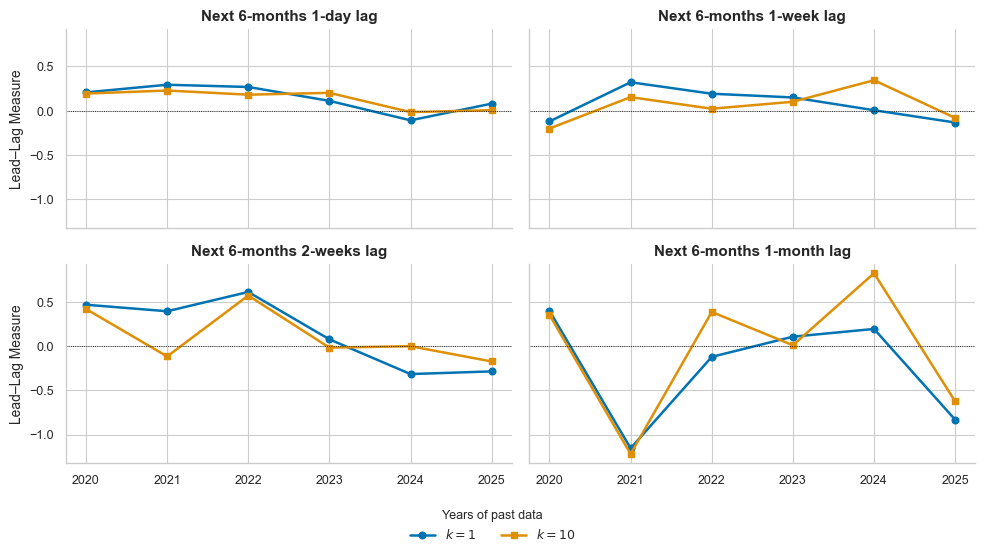

In [16]:
out_of_sample_lead_lag(n_months=6)

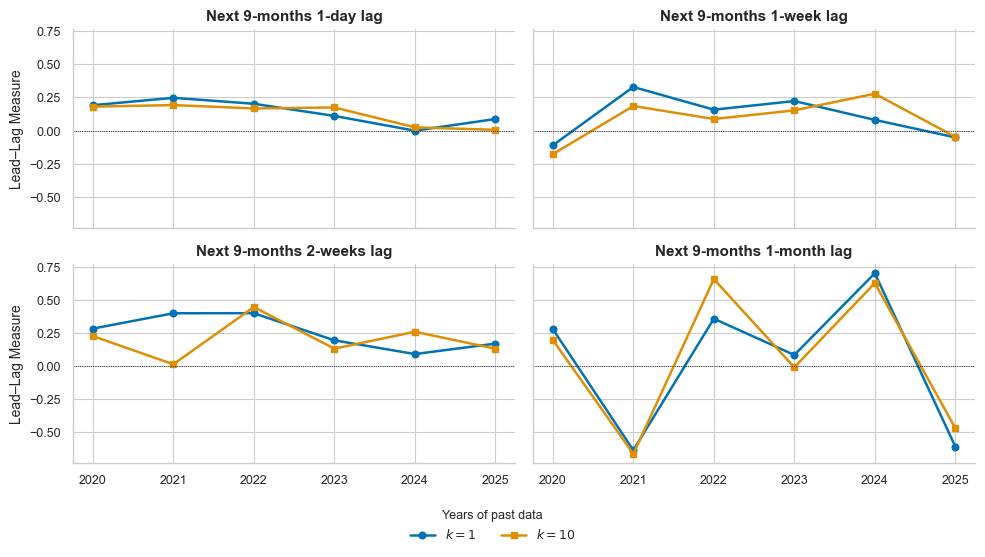

In [17]:
out_of_sample_lead_lag(n_months=9)

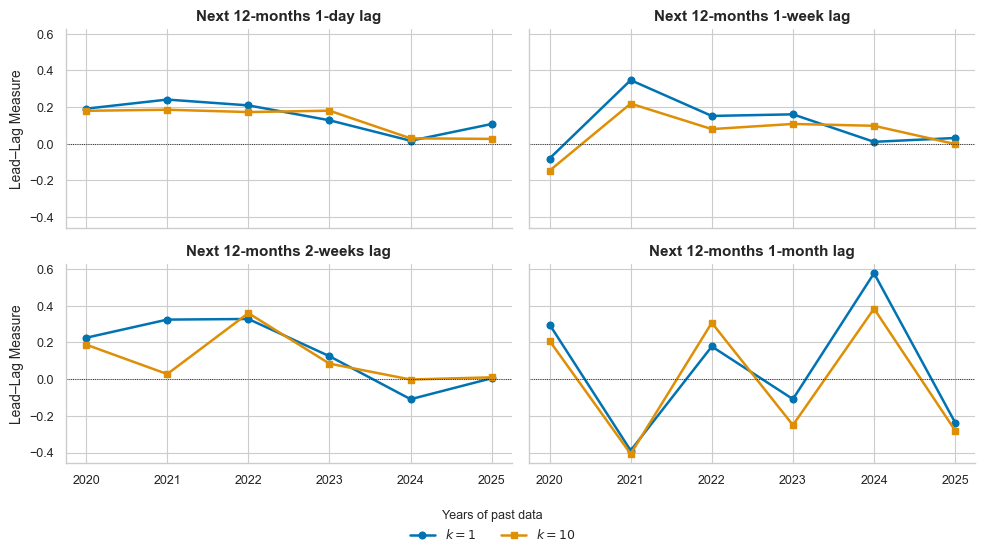

In [18]:
out_of_sample_lead_lag(n_months=12)